In [1]:
import pandas as pd
df = pd.read_csv("../data/preprocessed_star_data.csv")
X = df.drop(['Spectral Class','Star type'],axis=1)
y = df['Spectral Class']

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, f1_score
from typing import Tuple
import numpy as np


def hyperparameter_tuning_rfc() -> Tuple[dict, dict]:
    ht_rfc = RandomForestClassifier(n_jobs=-1)

    param_grid = {
        "n_estimators": np.arange(0, 700, 50),
        "max_depth": np.arange(1, 20),
        "criterion": ["gini", "entropy"]
    }

    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='macro'),
        'f1': make_scorer(f1_score, average='macro')
    }

    model = RandomizedSearchCV(
        estimator=ht_rfc,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        verbose=10,
        n_jobs=1,
        cv=5,
        refit='accuracy'
    )

    model.fit(X, y)
    best_params = model.best_estimator_.get_params()
    best_scores = {
        'accuracy': model.best_score_,
        'precision': model.cv_results_['mean_test_precision'][model.best_index_],
        'f1': model.cv_results_['mean_test_f1'][model.best_index_]
    }

    return best_params, best_scores

rfc_params, rfc_scores = hyperparameter_tuning_rfc()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START criterion=gini, max_depth=10, n_estimators=100.............
[CV 1/5; 1/10] END criterion=gini, max_depth=10, n_estimators=100; accuracy: (test=0.896) f1: (test=0.832) precision: (test=0.831) total time=   0.1s
[CV 2/5; 1/10] START criterion=gini, max_depth=10, n_estimators=100.............
[CV 2/5; 1/10] END criterion=gini, max_depth=10, n_estimators=100; accuracy: (test=0.917) f1: (test=0.845) precision: (test=0.846) total time=   0.1s
[CV 3/5; 1/10] START criterion=gini, max_depth=10, n_estimators=100.............


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[CV 3/5; 1/10] END criterion=gini, max_depth=10, n_estimators=100; accuracy: (test=0.958) f1: (test=0.938) precision: (test=0.948) total time=   0.1s
[CV 4/5; 1/10] START criterion=gini, max_depth=10, n_estimators=100.............
[CV 4/5; 1/10] END criterion=gini, max_depth=10, n_estimators=100; accuracy: (test=0.917) f1: (test=0.819) precision: (test=0.907) total time=   0.1s
[CV 5/5; 1/10] START criterion=gini, max_depth=10, n_estimators=100.............
[CV 5/5; 1/10] END criterion=gini, max_depth=10, n_estimators=100; accuracy: (test=0.750) f1: (test=0.448) precision: (test=0.561) total time=   0.1s
[CV 1/5; 2/10] START criterion=entropy, max_depth=16, n_estimators=550..........


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 1/5; 2/10] END criterion=entropy, max_depth=16, n_estimators=550; accuracy: (test=0.875) f1: (test=0.782) precision: (test=0.787) total time=   0.2s
[CV 2/5; 2/10] START criterion=entropy, max_depth=16, n_estimators=550..........
[CV 2/5; 2/10] END criterion=entropy, max_depth=16, n_estimators=550; accuracy: (test=0.917) f1: (test=0.845) precision: (test=0.846) total time=   0.2s
[CV 3/5; 2/10] START criterion=entropy, max_depth=16, n_estimators=550..........
[CV 3/5; 2/10] END criterion=entropy, max_depth=16, n_estimators=550; accuracy: (test=0.958) f1: (test=0.938) precision: (test=0.948) total time=   0.2s
[CV 4/5; 2/10] START criterion=entropy, max_depth=16, n_estimators=550..........
[CV 4/5; 2/10] END criterion=entropy, max_depth=16, n_estimators=550; accuracy: (test=0.917) f1: (test=0.819) precision: (test=0.907) total time=   0.2s
[CV 5/5; 2/10] START criterion=entropy, max_depth=16, n_estimators=550..........


...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 1/5; 10/10] END criterion=gini, max_depth=1, n_estimators=250; accuracy: (test=0.646) f1: (test=0.281) precision: (test=0.246) total time=   0.1s
[CV 2/5; 10/10] START criterion=gini, max_depth=1, n_estimators=250.............
[CV 2/5; 10/10] END criterion=gini, max_depth=1, n_estimators=250; accuracy: (test=0.625) f1: (test=0.277) precision: (test=0.242) total time=   0.1s
[CV 3/5; 10/10] START criterion=gini, max_depth=1, n_estimators=250.............
[CV 3/5; 10/10] END criterion=gini, max_depth=1, n_estimators=250; accuracy: (test=0.625) f1: (test=0.277) precision: (test=0.242) total time=   0.1s
[CV 4/5; 10/10] START criterion=gini, max_depth=1, n_estimators=250.............


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 4/5; 10/10] END criterion=gini, max_depth=1, n_estimators=250; accuracy: (test=0.646) f1: (test=0.285) precision: (test=0.252) total time=   0.1s
[CV 5/5; 10/10] START criterion=gini, max_depth=1, n_estimators=250.............
[CV 5/5; 10/10] END criterion=gini, max_depth=1, n_estimators=250; accuracy: (test=0.812) f1: (test=0.391) precision: (test=0.362) total time=   0.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import SVC

def hyperparameter_tuning_svm() -> Tuple[dict, dict]:
    ht_svm = SVC()

    param_grid = {
        "C": np.logspace(-3, 3, 7),
        "gamma": np.logspace(-3, 3, 7),
        "kernel": ["linear", "rbf", "poly", "sigmoid"]
    }

    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='macro'),
        'f1': make_scorer(f1_score, average='macro')
    }

    model = RandomizedSearchCV(
        estimator=ht_svm,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        verbose=10,
        n_jobs=1,
        cv=5,
        refit='accuracy'  # Choose one metric for refitting the estimator
    )

    model.fit(X, y)
    best_params = model.best_estimator_.get_params()
    best_scores = {
        'accuracy': model.best_score_,
        'precision': model.cv_results_['mean_test_precision'][model.best_index_],
        'f1': model.cv_results_['mean_test_f1'][model.best_index_]
    }

    return best_params, best_scores

svm_params, svm_scores = hyperparameter_tuning_svm()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START C=0.01, gamma=1.0, kernel=sigmoid..........................
[CV 1/5; 1/10] END C=0.01, gamma=1.0, kernel=sigmoid; accuracy: (test=0.479) f1: (test=0.108) precision: (test=0.080) total time=   0.0s
[CV 2/5; 1/10] START C=0.01, gamma=1.0, kernel=sigmoid..........................
[CV 2/5; 1/10] END C=0.01, gamma=1.0, kernel=sigmoid; accuracy: (test=0.458) f1: (test=0.105) precision: (test=0.076) total time=   0.0s
[CV 3/5; 1/10] START C=0.01, gamma=1.0, kernel=sigmoid..........................
[CV 3/5; 1/10] END C=0.01, gamma=1.0, kernel=sigmoid; accuracy: (test=0.458) f1: (test=0.105) precision: (test=0.076) total time=   0.0s
[CV 4/5; 1/10] START C=0.01, gamma=1.0, kernel=sigmoid..........................
[CV 4/5; 1/10] END C=0.01, gamma=1.0, kernel=sigmoid; accuracy: (test=0.458) f1: (test=0.105) precision: (test=0.076) total time=   0.0s
[CV 5/5; 1/10] START C=0.01, gamma=1.0, kernel=sigmoid.............

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/

[CV 1/5; 2/10] END C=10.0, gamma=0.001, kernel=poly; accuracy: (test=0.292) f1: (test=0.388) precision: (test=0.515) total time=   0.2s
[CV 2/5; 2/10] START C=10.0, gamma=0.001, kernel=poly...........................
[CV 2/5; 2/10] END C=10.0, gamma=0.001, kernel=poly; accuracy: (test=0.750) f1: (test=0.604) precision: (test=0.618) total time=   0.2s
[CV 3/5; 2/10] START C=10.0, gamma=0.001, kernel=poly...........................


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 3/5; 2/10] END C=10.0, gamma=0.001, kernel=poly; accuracy: (test=0.792) f1: (test=0.546) precision: (test=0.556) total time=   0.2s
[CV 4/5; 2/10] START C=10.0, gamma=0.001, kernel=poly...........................
[CV 4/5; 2/10] END C=10.0, gamma=0.001, kernel=poly; accuracy: (test=0.917) f1: (test=0.734) precision: (test=0.754) total time=   0.1s
[CV 5/5; 2/10] START C=10.0, gamma=0.001, kernel=poly...........................


...

[CV 3/5; 5/10] END C=1.0, gamma=1.0, kernel=linear; accuracy: (test=0.875) f1: (test=0.605) precision: (test=0.569) total time=   0.3s
[CV 4/5; 5/10] START C=1.0, gamma=1.0, kernel=linear............................


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 4/5; 5/10] END C=1.0, gamma=1.0, kernel=linear; accuracy: (test=0.833) f1: (test=0.549) precision: (test=0.608) total time=   0.5s
[CV 5/5; 5/10] START C=1.0, gamma=1.0, kernel=linear............................


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

[CV 5/5; 5/10] END C=1.0, gamma=1.0, kernel=linear; accuracy: (test=0.812) f1: (test=0.387) precision: (test=0.360) total time=   0.2s
[CV 1/5; 6/10] START C=10.0, gamma=100.0, kernel=sigmoid........................
[CV 1/5; 6/10] END C=10.0, gamma=100.0, kernel=sigmoid; accuracy: (test=0.479) f1: (test=0.108) precision: (test=0.080) total time=   0.0s
[CV 2/5; 6/10] START C=10.0, gamma=100.0, kernel=sigmoid........................
[CV 2/5; 6/10] END C=10.0, gamma=100.0, kernel=sigmoid; accuracy: (test=0.458) f1: (test=0.105) precision: (test=0.076) total time=   0.0s
[CV 3/5; 6/10] START C=10.0, gamma=100.0, kernel=sigmoid........................
[CV 3/5; 6/10] END C=10.0, gamma=100.0, kernel=sigmoid; accuracy: (test=0.458) f1: (test=0.105) precision: (test=0.076) total time=   0.0s
[CV 4/5; 6/10] START C=10.0, gamma=100.0, kernel=sigmoid........................
[CV 4/5; 6/10] END C=10.0, gamma=100.0, kernel=sigmoid; accuracy: (test=0.458) f1: (test=0.105) precision: (test=0.076) tota

In [6]:
from sklearn.neighbors import KNeighborsClassifier

def hyperparameter_tuning_knn() -> Tuple[dict, dict]:
    ht_knn = KNeighborsClassifier()

    param_grid = {
        "n_neighbors": np.arange(1, 31),
        "weights": ["uniform", "distance"],
        "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
        "p": [1, 2]
    }

    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='macro'),
        'f1': make_scorer(f1_score, average='macro')
    }

    model = RandomizedSearchCV(
        estimator=ht_knn,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        verbose=10,
        n_jobs=1,
        cv=5,
        refit='accuracy'
    )

    model.fit(X, y)
    best_params = model.best_estimator_.get_params()
    best_scores = {
        'accuracy': model.best_score_,
        'precision': model.cv_results_['mean_test_precision'][model.best_index_],
        'f1': model.cv_results_['mean_test_f1'][model.best_index_]
    }

    return best_params, best_scores

knn_params, knn_scores = hyperparameter_tuning_knn()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START algorithm=auto, n_neighbors=4, p=1, weights=distance.......
[CV 1/5; 1/10] END algorithm=auto, n_neighbors=4, p=1, weights=distance; accuracy: (test=0.917) f1: (test=0.878) precision: (test=0.910) total time=   0.0s
[CV 2/5; 1/10] START algorithm=auto, n_neighbors=4, p=1, weights=distance.......
[CV 2/5; 1/10] END algorithm=auto, n_neighbors=4, p=1, weights=distance; accuracy: (test=0.958) f1: (test=0.922) precision: (test=0.898) total time=   0.0s
[CV 3/5; 1/10] START algorithm=auto, n_neighbors=4, p=1, weights=distance.......
[CV 3/5; 1/10] END algorithm=auto, n_neighbors=4, p=1, weights=distance; accuracy: (test=0.979) f1: (test=0.980) precision: (test=0.981) total time=   0.0s
[CV 4/5; 1/10] START algorithm=auto, n_neighbors=4, p=1, weights=distance.......
[CV 4/5; 1/10] END algorithm=auto, n_neighbors=4, p=1, weights=distance; accuracy: (test=0.917) f1: (test=0.724) precision: (test=0.712) total time

c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\skl

[CV 1/5; 3/10] END algorithm=brute, n_neighbors=30, p=2, weights=uniform; accuracy: (test=0.833) f1: (test=0.570) precision: (test=0.655) total time=   0.2s
[CV 2/5; 3/10] START algorithm=brute, n_neighbors=30, p=2, weights=uniform......
[CV 2/5; 3/10] END algorithm=brute, n_neighbors=30, p=2, weights=uniform; accuracy: (test=0.771) f1: (test=0.459) precision: (test=0.531) total time=   0.0s
[CV 3/5; 3/10] START algorithm=brute, n_neighbors=30, p=2, weights=uniform......
[CV 3/5; 3/10] END algorithm=brute, n_neighbors=30, p=2, weights=uniform; accuracy: (test=0.812) f1: (test=0.503) precision: (test=0.567) total time=   0.0s
[CV 4/5; 3/10] START algorithm=brute, n_neighbors=30, p=2, weights=uniform......
[CV 4/5; 3/10] END algorithm=brute, n_neighbors=30, p=2, weights=uniform; accuracy: (test=0.646) f1: (test=0.288) precision: (test=0.254) total time=   0.0s
[CV 5/5; 3/10] START algorithm=brute, n_neighbors=30, p=2, weights=uniform......
[CV 5/5; 3/10] END algorithm=brute, n_neighbors=

c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [7]:
from sklearn.tree import DecisionTreeClassifier

def hyperparameter_tuning_tree() -> Tuple[dict, dict]:
    ht_dtc = DecisionTreeClassifier()

    param_grid = {
        "max_depth": np.arange(1, 20),
        "min_samples_split": np.arange(2, 21),
        "min_samples_leaf": np.arange(1, 21),
        "criterion": ["gini", "entropy"]
    }

    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='macro'),
        'f1': make_scorer(f1_score, average='macro')
    }

    model = RandomizedSearchCV(
        estimator=ht_dtc,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        verbose=10,
        n_jobs=1,
        cv=5,
        refit='accuracy'
    )

    model.fit(X, y)

    best_params = model.best_estimator_.get_params()
    best_scores = {
        'accuracy': model.best_score_,
        'precision': model.cv_results_['mean_test_precision'][model.best_index_],
        'f1': model.cv_results_['mean_test_f1'][model.best_index_]
    }

    return best_params, best_scores

tree_params, tree_scores = hyperparameter_tuning_tree()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9
[CV 1/5; 1/10] END criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9; accuracy: (test=0.771) f1: (test=0.477) precision: (test=0.462) total time=   0.0s
[CV 2/5; 1/10] START criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9
[CV 2/5; 1/10] END criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9; accuracy: (test=0.792) f1: (test=0.574) precision: (test=0.682) total time=   0.0s
[CV 3/5; 1/10] START criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9
[CV 3/5; 1/10] END criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9; accuracy: (test=0.792) f1: (test=0.488) precision: (test=0.461) total time=   0.0s
[CV 4/5; 1/10] START criterion=entropy, max_depth=16, min_samples_leaf=17, min_samples_split=9
[CV 4/5; 1/10] END criterion

c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\skl

[CV 2/5; 3/10] END criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16; accuracy: (test=0.854) f1: (test=0.817) precision: (test=0.870) total time=   0.0s
[CV 3/5; 3/10] START criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16
[CV 3/5; 3/10] END criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16; accuracy: (test=0.917) f1: (test=0.845) precision: (test=0.915) total time=   0.0s
[CV 4/5; 3/10] START criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16
[CV 4/5; 3/10] END criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16; accuracy: (test=0.938) f1: (test=0.876) precision: (test=0.958) total time=   0.0s
[CV 5/5; 3/10] START criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16
[CV 5/5; 3/10] END criterion=entropy, max_depth=8, min_samples_leaf=4, min_samples_split=16; accuracy: (test=0.750) f1: (test=0.496) precision: (test=0.544) total time=   0.0s
[CV 1/5; 4/10]

c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

[CV 1/5; 10/10] END criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16; accuracy: (test=0.812) f1: (test=0.702) precision: (test=0.718) total time=   0.0s
[CV 2/5; 10/10] START criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16
[CV 2/5; 10/10] END criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16; accuracy: (test=0.854) f1: (test=0.817) precision: (test=0.870) total time=   0.0s
[CV 3/5; 10/10] START criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16
[CV 3/5; 10/10] END criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16; accuracy: (test=0.917) f1: (test=0.845) precision: (test=0.915) total time=   0.0s
[CV 4/5; 10/10] START criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16
[CV 4/5; 10/10] END criterion=entropy, max_depth=12, min_samples_leaf=3, min_samples_split=16; accuracy: (test=0.938) f1: (test=0.876) precision: (test=0.958) total time=   0.0s


c:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
print("Random Forest Scores:", rfc_scores)
print("SVM Scores:", svm_scores)
print("KNN Scores: ", knn_scores)
print("Tree Scores: ", tree_scores)

Random Forest Scores: {'accuracy': 0.9208333333333332, 'precision': 0.8884028169897735, 'f1': 0.8443204139155143}
SVM Scores: {'accuracy': 0.9083333333333332, 'precision': 0.8231671267540832, 'f1': 0.8100397741233655}
KNN Scores:  {'accuracy': 0.9375, 'precision': 0.8316098876968441, 'f1': 0.8263079711925452}
Tree Scores:  {'accuracy': 0.8833333333333332, 'precision': 0.8224929971988797, 'f1': 0.7942111403102114}


In [9]:
# Choosing Random Forest because precision and F1 scores are higher than KNN
# Although KNN has higher accuracy, RF'S higher F1 score indicates better balance between precision and recall
# Higher F1 is crucial in imbalanced datasets like the one we are using

rfc_params

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 13,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [10]:
rfc = RandomForestClassifier(**rfc_params)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        11
         1.0       0.93      1.00      0.96        13
         2.0       1.00      0.50      0.67         2
         3.0       0.75      1.00      0.86         3
         5.0       1.00      0.33      0.50         3
         6.0       0.97      1.00      0.98        28

    accuracy                           0.95        60
   macro avg       0.94      0.81      0.83        60
weighted avg       0.96      0.95      0.94        60



In [14]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: { precision_score(y_test, y_pred,average='weighted') }")

Accuracy: 0.95
Precision: 0.955931855500821


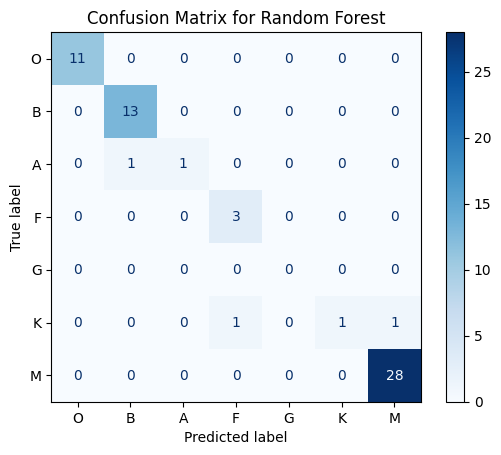

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=rfc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['O','B','A','F','G','K','M'])
disp.plot(cmap=plt.cm.Blues, values_format='d') 
plt.title('Confusion Matrix for Random Forest')
plt.show()